In [42]:
from pathlib import Path
from textwrap import fill
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml


In [ ]:
ROOT = Path('/home/tntiniak/Work/observatory_benchmark')

BIODYNAMO_DIR = ROOT / 'Biodynamo' / 'mechanics_hertz_relaxation' / 'results_drag_1'
CHASTE_DIR = ROOT / 'Chaste' / 'HertzCellRelaxation'
COMPUTIX_DIR = ROOT / 'CompuTiX' / 'overlap_relaxation'
PHYSICELL_DIR = ROOT / 'PhysiCell' / 'results' / 'mechanics_pushing_extended_hertz'
TiSIM_DIR = ROOT / 'Tisim' / 'mechanics_relaxation'


In [ ]:
# ── BioDynaMo ──────────────────────────────────────────────────────────
bdm_df = pd.read_csv(BIODYNAMO_DIR / 'positions.csv', sep='\t|,', header=None, engine='python')
bdm_time = bdm_df[0].to_numpy()
bdm_distance = (bdm_df[4] - bdm_df[1]).abs().to_numpy()

# ── Chaste ─────────────────────────────────────────────────────────────
chaste_df = pd.read_csv(CHASTE_DIR / 'node_locations.dat', sep='\s+', header=None)
chaste_time = chaste_df[0].to_numpy()
chaste_distance = (chaste_df[4] - chaste_df[1]).abs().to_numpy() * 1e6  # m -> µm

# ── CompuTiX ───────────────────────────────────────────────────────────
with open(COMPUTIX_DIR / 'results_mu_1.yaml') as f:
    ctix = yaml.safe_load(f)
ctix_time = np.array(ctix['t']['values'])
ctix_positions = np.array(ctix['Cells']['values']['x']['values'])
ctix_distance = np.abs(ctix_positions[:, 1] - ctix_positions[:, 0]) * 1e6  # m -> µm

# ── PhysiCell ──────────────────────────────────────────────────────────
pc_df = pd.read_csv(PHYSICELL_DIR / 'physicell_mechanics_pushing_extended_hertz.csv')
pc_time = pc_df['time_min'].to_numpy() * 60  # min -> s
pc_distance = pc_df['distance_um'].to_numpy()

# ── TiSim ──────────────────────────────────────────────────────────────
tisim_df = pd.read_csv(TiSIM_DIR / 'data_drag_1.csv')
tisim_time = tisim_df['time_s'].to_numpy()
tisim_distance = tisim_df['distance_10um'].to_numpy() * 10


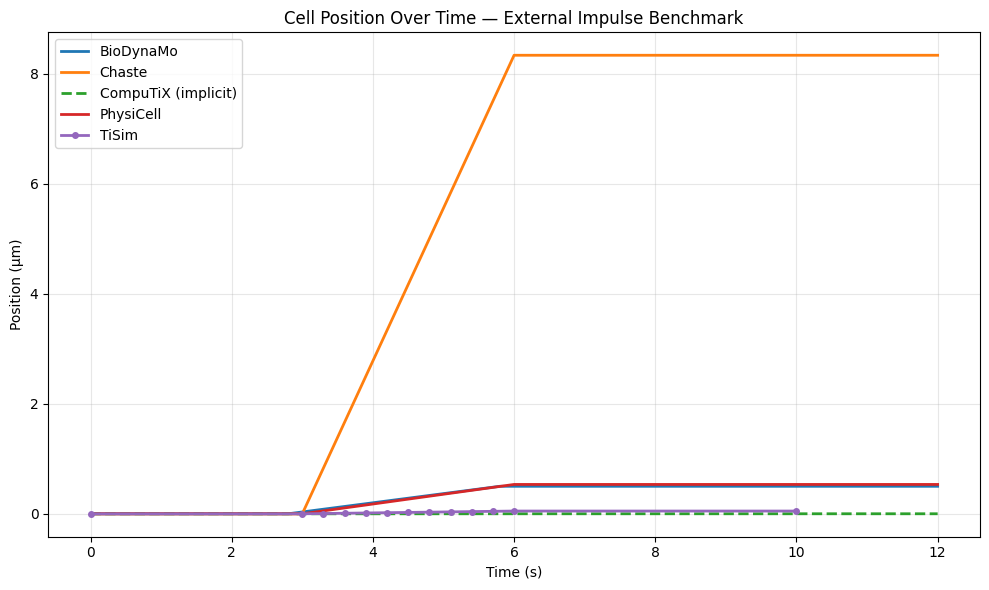

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(bdm_time, bdm_distance, label='BioDynaMo', lw=2)
ax.plot(chaste_time, chaste_distance, label='Chaste', lw=2)
ax.plot(ctix_time, ctix_distance, label='CompuTiX', lw=2, ls='--')
ax.plot(pc_time, pc_distance, label='PhysiCell', lw=2)
ax.plot(tisim_time, tisim_distance, label='TiSim', lw=2, marker='o', ms=4)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Distance between cell centers (µm)')
ax.set_title('Distance Between Cell Centers Over Time — Extended Hertz Benchmark')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'ResultAnalysis' / 'plots' / 'mechanics_pushing_external_hertz_distance.png', dpi=150)
plt.show()


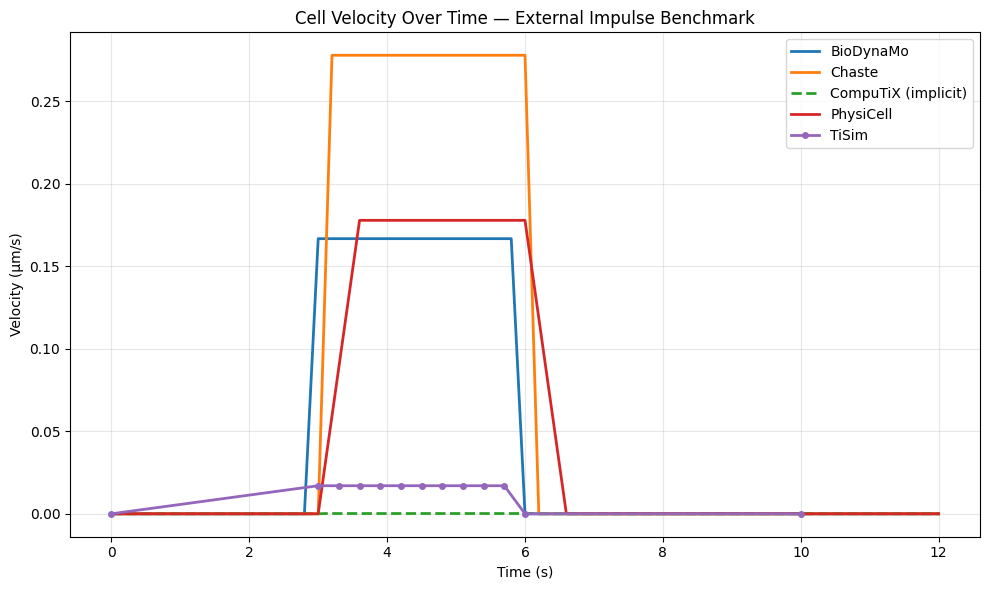

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

max_time = 2400

ax.plot(bdm_time[bdm_time <= max_time], bdm_distance[bdm_time <= max_time], label='BioDynaMo', lw=2)
ax.plot(chaste_time[chaste_time <= max_time], chaste_distance[chaste_time <= max_time], label='Chaste', lw=2)
ax.plot(ctix_time[ctix_time <= max_time], ctix_distance[ctix_time <= max_time], label='CompuTiX', lw=2, ls='--')
ax.plot(pc_time[pc_time <= max_time], pc_distance[pc_time <= max_time], label='PhysiCell', lw=2)
ax.plot(tisim_time[tisim_time <= max_time], tisim_distance[tisim_time <= max_time], label='TiSim', lw=2, marker='o', ms=4)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Distance between cell centers (µm)')
ax.set_title('Distance Between Cell Centers Over Time — First 40 Minutes')
ax.set_xlim(0, max_time)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'ResultAnalysis' / 'plots' / 'mechanics_pushing_external_hertz_distance_zoom.png', dpi=150)
plt.show()
